# Image Enhancement
**Tugas:** Implementasi *image enhancement* untuk berbagai tipe/kondisi citra
(dark image, bright image, low-contrast, blurred, noisy, dsb), dengan
**citra sumber yang berbeda-beda di setiap kondisi**.

**Daftar isi (kondisi citra, citra sumber, & metode):**

| No | Kondisi Citra | Citra Sumber | Metode Enhancement |
|----|----------------|--------------|---------------------|
| 1 | Dark image (underexposed) | Potret dalam ruangan gelap | Histogram Equalization |
| 2 | Dark image | Gang malam hari | Logarithmic Transform |
| 3 | Dark image | Interior gua | Gamma Correction (γ<1) |
| 4 | Bright / overexposed | Pegunungan bersalju | Gamma Correction (γ>1) |
| 5 | Bright image | Langit mendung terang | Histogram Equalization |
| 6 | Low-contrast image | Pelabuhan berkabut | Contrast Stretching |
| 7 | Detail terang di bg gelap | Rontgen tangan sintetis | Image Negative |
| 8 | Highlight rentang intensitas | Peta termal | Gray-level Slicing |
| 9 | Noise ringan di bit rendah | Koran lama terpindai | Bit-plane Slicing & Reconstruction |
| 10 | Salt & Pepper noise | Keranjang buah (still life) | Median Filter |
| 11 | Gaussian / random noise | Nebula | Gaussian Smoothing Filter |
| 12 | Banyak frame noisy | Gugus bintang (galaxy cluster) | Image Averaging |
| 13 | Blurred image | Siluet kota (city skyline) | Sharpening — Laplacian Filter |
| 14 | Soft-focus / sedikit blur | Bunga makro | Unsharp Masking |
| 15 | Periodic / interference noise | Kain tenun bergaris | Frequency-Domain Low-Pass Filter |

## 1. Setup & Import

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

%matplotlib inline


## 2. Fungsi-fungsi Enhancement

In [8]:
import numpy as np

def clip_uint8(img):
    out = np.clip(img, 0, 255)
    return out.astype(np.uint8)

def pad_image(img, pad, mode="replicate"):
    h, w = img.shape
    padded = np.zeros((h + 2 * pad, w + 2 * pad), dtype=img.dtype)
    padded[pad:pad + h, pad:pad + w] = img

    if mode == "replicate":
        padded[:pad, pad:pad + w] = img[0, :]
        padded[pad + h:, pad:pad + w] = img[-1, :]
        padded[pad:pad + h, :pad] = img[:, [0]]
        padded[pad:pad + h, pad + w:] = img[:, [-1]]
        padded[:pad, :pad] = img[0, 0]
        padded[:pad, pad + w:] = img[0, -1]
        padded[pad + h:, :pad] = img[-1, 0]
        padded[pad + h:, pad + w:] = img[-1, -1]
    return padded

def image_negative(img, L=256):
    img = img.astype(np.float64)
    s = (L - 1) - img
    return clip_uint8(s)

def log_transform(img):
    img = img.astype(np.float64)
    r_max = np.max(img)
    c = 255.0 / np.log(1 + r_max) if r_max > 0 else 1.0
    s = c * np.log(1 + img)
    return clip_uint8(s)

def gamma_correction(img, gamma, c=1.0):
    img_norm = img.astype(np.float64) / 255.0
    s = c * np.power(img_norm, gamma)
    return clip_uint8(s * 255.0)

def contrast_stretching(img, a=0, b=255, low_percentile=0, high_percentile=100):
    img = img.astype(np.float64)
    lo = np.percentile(img, low_percentile)
    hi = np.percentile(img, high_percentile)
    if hi - lo == 0:
        return clip_uint8(img)
    out = (img - lo) * (b - a) / (hi - lo) + a
    return clip_uint8(out)

def gray_level_slicing(img, A, B, preserve_background=True, high_value=255):
    img = img.astype(np.float64)
    out = np.copy(img) if preserve_background else np.zeros_like(img)
    mask = (img >= A) & (img <= B)
    out[mask] = high_value
    return clip_uint8(out)

def bit_plane_slicing(img):
    planes = []
    for k in range(8):
        plane = (img >> k) & 1
        planes.append((plane * 255).astype(np.uint8))
    return planes

def bit_plane_reconstruct(img, planes_to_keep):
    out = np.zeros_like(img, dtype=np.int32)
    for k in planes_to_keep:
        bit = (img >> k) & 1
        out += (bit << k)
    return clip_uint8(out)

def compute_histogram(img, L=256):
    hist = np.zeros(L, dtype=np.int64)
    flat = img.flatten()
    for level in range(L):
        hist[level] = np.sum(flat == level)
    return hist

def histogram_equalization(img, L=256):
    h, w = img.shape
    n_pixels = h * w

    hist = compute_histogram(img, L)
    pmf = hist / n_pixels

    cdf = np.zeros(L, dtype=np.float64)
    running_sum = 0.0
    for k in range(L):
        running_sum += pmf[k]
        cdf[k] = running_sum

    lut = np.round((L - 1) * cdf).astype(np.uint8)

    out = np.zeros_like(img)
    for k in range(L):
        out[img == k] = lut[k]
    return out, hist, lut

def convolve2d_manual(img, kernel, normalize=False):
    img = img.astype(np.float64)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    kernel_rot = kernel[::-1, ::-1]

    padded = pad_image(img, max(pad_h, pad_w), mode="replicate")
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float64)

    for i in range(h):
        for j in range(w):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel_rot)

    if normalize:
        k_sum = np.sum(kernel)
        if k_sum != 0:
            out = out / k_sum
    return out

def mean_filter(img, ksize=3):
    kernel = np.ones((ksize, ksize), dtype=np.float64)
    out = convolve2d_manual(img, kernel, normalize=True)
    return clip_uint8(out)

def gaussian_kernel_manual(ksize=5, sigma=1.0):
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

def gaussian_filter(img, ksize=5, sigma=1.0):
    kernel = gaussian_kernel_manual(ksize, sigma)
    out = convolve2d_manual(img, kernel, normalize=False)
    return clip_uint8(out)

def median_filter_manual(img, ksize=3):
    img = img.astype(np.float64)
    pad = ksize // 2
    padded = pad_image(img, pad, mode="replicate")
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float64)

    for i in range(h):
        for j in range(w):
            window = padded[i:i + ksize, j:j + ksize]
            out[i, j] = np.median(window)
    return clip_uint8(out)

def laplacian_sharpen(img, mode="4-neighbor"):
    if mode == "4-neighbor":
        kernel = np.array([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=np.float64)
    else:
        kernel = np.array([[1, 1, 1],
                            [1, -8, 1],
                            [1, 1, 1]], dtype=np.float64)

    lap = convolve2d_manual(img, kernel, normalize=False)
    sharpened = img.astype(np.float64) - lap
    return clip_uint8(sharpened)

def unsharp_masking(img, ksize=5, sigma=1.5, k=1.0):
    img_f = img.astype(np.float64)
    blurred = gaussian_filter(img, ksize, sigma).astype(np.float64)
    mask = img_f - blurred
    sharpened = img_f + k * mask
    return clip_uint8(sharpened)

def add_gaussian_noise(img, mean=0, sigma=20, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.normal(mean, sigma, img.shape)
    return clip_uint8(img.astype(np.float64) + noise)

def add_salt_pepper_noise(img, amount=0.05, salt_ratio=0.5, seed=None):
    rng = np.random.default_rng(seed)
    out = img.copy()
    h, w = img.shape
    n_pixels = int(amount * h * w)

    n_salt = int(n_pixels * salt_ratio)
    coords_salt = (rng.integers(0, h, n_salt), rng.integers(0, w, n_salt))
    out[coords_salt] = 255

    n_pepper = n_pixels - n_salt
    coords_pepper = (rng.integers(0, h, n_pepper), rng.integers(0, w, n_pepper))
    out[coords_pepper] = 0
    return out

def image_averaging(list_of_noisy_images):
    K = len(list_of_noisy_images)
    h, w = list_of_noisy_images[0].shape
    accumulator = np.zeros((h, w), dtype=np.float64)
    for g_i in list_of_noisy_images:
        accumulator += g_i.astype(np.float64)
    g_bar = accumulator / K
    return clip_uint8(g_bar)

def gaussian_lowpass_mask(shape, D0):
    M, N = shape
    u = np.arange(M).reshape(-1, 1) - M // 2
    v = np.arange(N).reshape(1, -1) - N // 2
    D = np.sqrt(u**2 + v**2)
    H = np.exp(-(D**2) / (2 * (D0**2)))
    return H

def frequency_lowpass_filter(img, D0=30):
    F = np.fft.fft2(img.astype(np.float64))
    Fshift = np.fft.fftshift(F)

    H = gaussian_lowpass_mask(img.shape, D0)
    Gshift = Fshift * H

    G = np.fft.ifftshift(Gshift)
    g = np.fft.ifft2(G)
    g = np.real(g)
    return clip_uint8(g), np.log1p(np.abs(Fshift)), H

## 3. Fungsi untuk Menampilkan Hasil (Before vs After)

In [9]:
def show_result(before, after, before_label, after_label, title,
                 show_hist=True, figsize=None):
    ncols = 2
    nrows = 2 if show_hist else 1
    fig, ax = plt.subplots(nrows, ncols, figsize=figsize or (8, 7 if show_hist else 4))
    if not show_hist:
        ax = ax.reshape(1, 2)

    ax[0, 0].imshow(before, cmap="gray", vmin=0, vmax=255)
    ax[0, 0].set_title(before_label); ax[0, 0].axis("off")

    ax[0, 1].imshow(after, cmap="gray", vmin=0, vmax=255)
    ax[0, 1].set_title(after_label); ax[0, 1].axis("off")

    if show_hist:
        ax[1, 0].hist(before.flatten(), bins=256, range=(0, 255), color="black")
        ax[1, 0].set_title("Histogram - " + before_label); ax[1, 0].set_xlim(0, 255)

        ax[1, 1].hist(after.flatten(), bins=256, range=(0, 255), color="black")
        ax[1, 1].set_title("Histogram - " + after_label); ax[1, 1].set_xlim(0, 255)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()
    print(f"Mean before = {before.mean():.2f} | Mean after = {after.mean():.2f}")

## 4. Pemuatan 15 Citra Sumber


In [10]:
import os
import numpy as np
from PIL import Image

SIZE = 256

def load_scene(filename, size=SIZE):
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"File '{filename}' tidak ditemukan di working directory.\n"
            f"-> Cek lagi: sudah di-upload ke Colab? namanya persis sama\n"
            f"   (huruf besar/kecil ikut berpengaruh)?"
        )
    img = Image.open(filename).convert("L")
    img = img.resize((size, size), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)

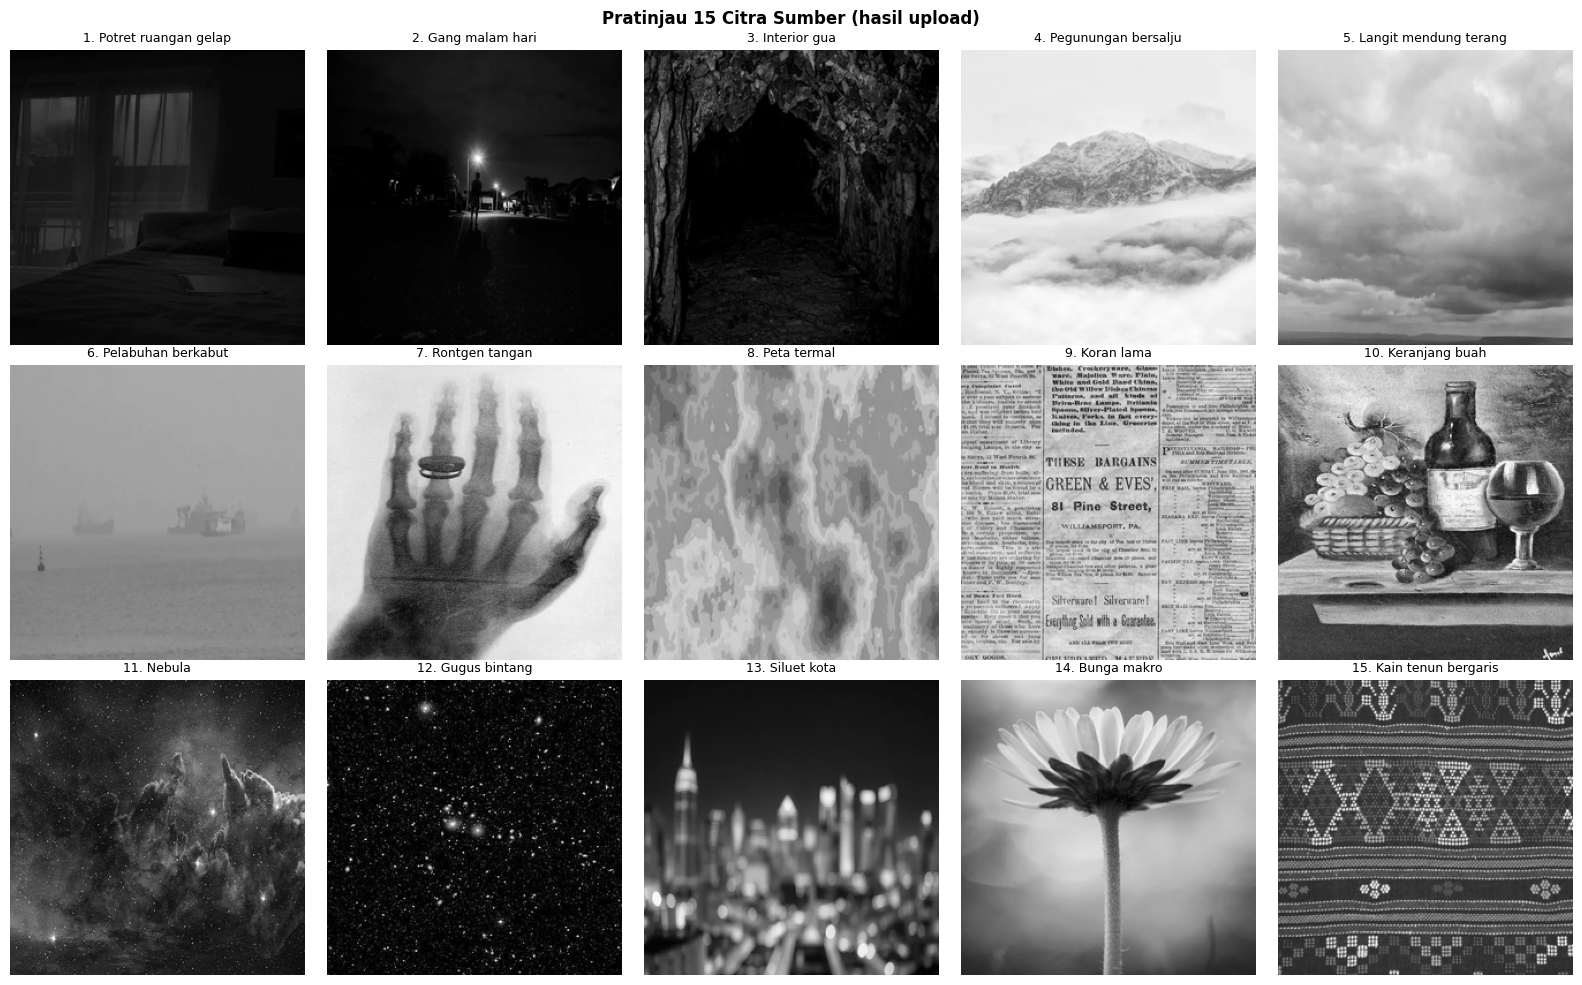

In [11]:
preview_list = [
    ("1. Potret ruangan gelap", "01_potret_gelap.jpg"),
    ("2. Gang malam hari", "02_gang_malam.jpg"),
    ("3. Interior gua", "03_interior_gua.jpg"),
    ("4. Pegunungan bersalju", "04_pegunungan_salju.jpg"),
    ("5. Langit mendung terang", "05_langit_mendung.jpg"),
    ("6. Pelabuhan berkabut", "06_pelabuhan_berkabut.jpg"),
    ("7. Rontgen tangan", "07_rontgen_tangan.jpg"),
    ("8. Peta termal", "08_peta_termal.jpg"),
    ("9. Koran lama", "09_koran_lama.jpg"),
    ("10. Keranjang buah", "10_keranjang_buah.jpg"),
    ("11. Nebula", "11_nebula.jpg"),
    ("12. Gugus bintang", "12_gugus_bintang.jpg"),
    ("13. Siluet kota", "13_siluet_kota.jpg"),
    ("14. Bunga makro", "14_bunga_makro.jpg"),
    ("15. Kain tenun bergaris", "15_kain_tenun.jpg"),
]

fig, axs = plt.subplots(3, 5, figsize=(16, 10))
for (label, fname), ax in zip(preview_list, axs.flat):
    try:
        img = load_scene(fname)
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    except FileNotFoundError:
        ax.imshow(np.zeros((SIZE, SIZE)), cmap="gray", vmin=0, vmax=255)
        ax.text(0.5, 0.5, "belum\ndi-upload", ha="center", va="center",
                fontsize=9, color="white", transform=ax.transAxes)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
fig.suptitle("Pratinjau 15 Citra Sumber (hasil upload)", fontweight="bold")
fig.tight_layout()
plt.show()


## Kondisi 1: Dark Image (Underexposed) &rarr; Histogram Equalization

**Citra sumber:** Potret dalam ruangan gelap

**Ciri-ciri:** histogram menumpuk di sisi kiri (gray-level rendah), citra
tampak gelap secara keseluruhan, wajah/objek nyaris tak terlihat.

**Metode:** *Histogram Equalization* — meratakan sebaran histogram ke seluruh
rentang intensitas [0, 255] menggunakan CDF, sehingga kontras & keterlihatan
detail meningkat secara otomatis (fully automatic, data dependent).

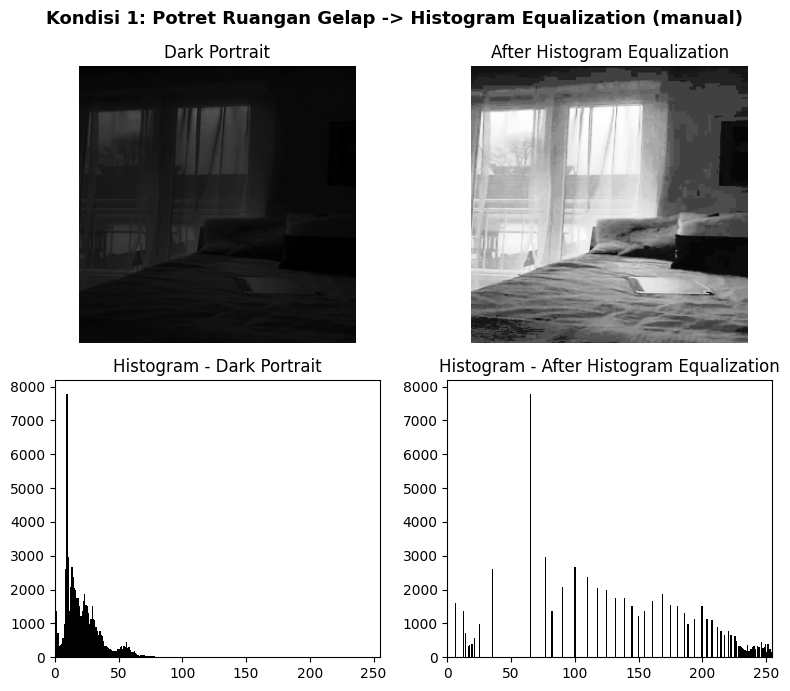

Mean before = 20.62 | Mean after = 131.91


In [12]:
img1 = load_scene("01_potret_gelap.jpg")
eq1, hist1, lut1 = histogram_equalization(img1)

show_result(img1, eq1, "Dark Portrait", "After Histogram Equalization",
            title="Kondisi 1: Potret Ruangan Gelap -> Histogram Equalization (manual)")

## Kondisi 2: Dark Image &rarr; Logarithmic Transform

**Citra sumber:** Gang malam hari dengan lampu jalan

**Ciri-ciri:** citra gelap namun ada sedikit sumber cahaya lokal (lampu
jalan) — ingin pendekatan *data-independent* (tidak bergantung histogram
citra secara keseluruhan).

**Metode:** *Log Transform* `s = c·log(1+r)` dengan `c = 255/log(1+r_max)`.
Fungsi logaritma mengekspansi rentang nilai gelap dan mengompresi rentang
nilai terang, sehingga siluet gedung & jalan lebih terlihat tanpa lampu
menjadi over-saturated.

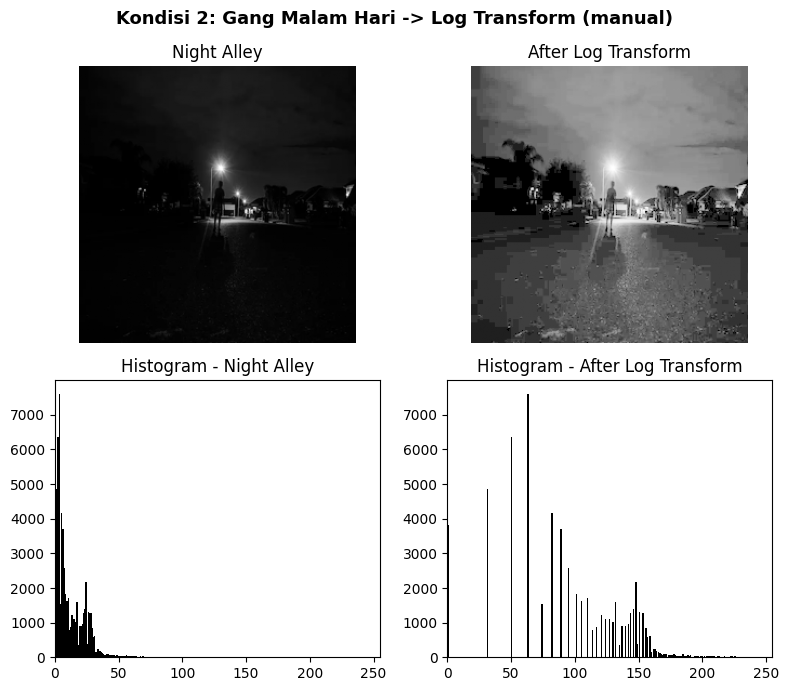

Mean before = 13.17 | Mean after = 96.07


In [13]:
img2 = load_scene("02_gang_malam.jpg")
log2 = log_transform(img2)

show_result(img2, log2, "Night Alley", "After Log Transform",
            title="Kondisi 2: Gang Malam Hari -> Log Transform (manual)")

## Kondisi 3: Dark Image &rarr; Gamma Correction (&gamma; &lt; 1)

**Citra sumber:** Interior gua

**Ciri-ciri:** citra sangat gelap merata (interior gua tanpa banyak
sumber cahaya), butuh pencerahan yang bisa dikontrol presisi lewat parameter
γ (tidak seagresif log transform).

**Metode:** *Power-law (Gamma) Transform* `s = c·r^γ` dengan `γ = 0.35`
(γ < 1 &rarr; mencerahkan area gelap tanpa membakar highlight).

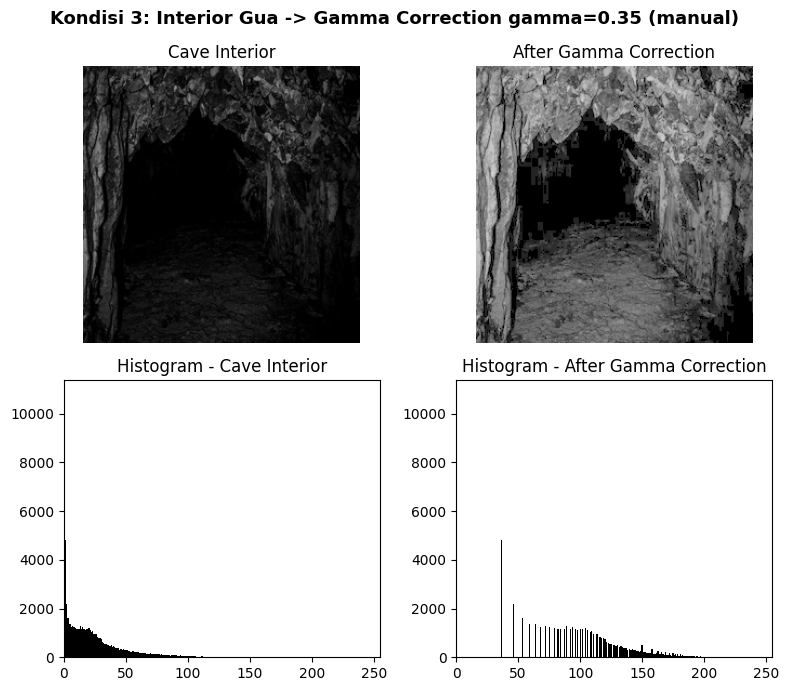

Mean before = 21.08 | Mean after = 84.08


In [14]:
img3 = load_scene("03_interior_gua.jpg")
gamma3 = gamma_correction(img3, gamma=0.35)

show_result(img3, gamma3, "Cave Interior", "After Gamma Correction",
            title="Kondisi 3: Interior Gua -> Gamma Correction gamma=0.35 (manual)")

## Kondisi 4: Bright / Overexposed Image &rarr; Gamma Correction (&gamma; &gt; 1)

**Citra sumber:** Pegunungan bersalju

**Ciri-ciri:** histogram menumpuk di sisi kanan (gray-level tinggi), citra
tampak abu putih dengan awan menyatu.

**Metode:** *Gamma Correction* dengan `γ = 3.0` (γ > 1 &rarr; menggelapkan/
mengompresi area terang, mengembalikan kontras & tekstur salju/gunung).

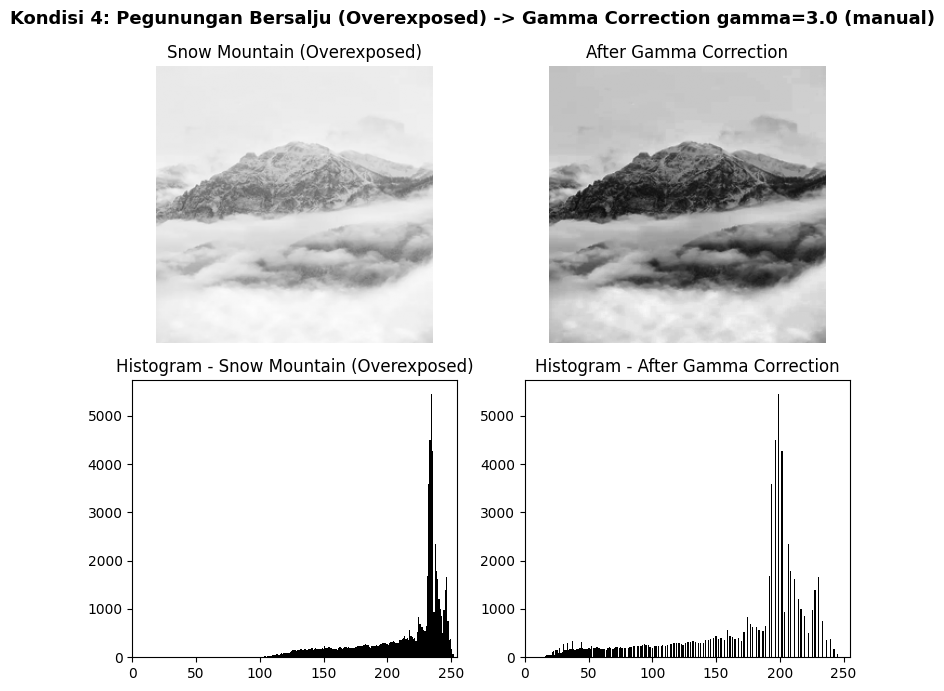

Mean before = 214.90 | Mean after = 162.93


In [15]:
img4 = load_scene("04_pegunungan_salju.jpg")
gamma4 = gamma_correction(img4, gamma=3.0)

show_result(img4, gamma4, "Snow Mountain (Overexposed)", "After Gamma Correction",
            title="Kondisi 4: Pegunungan Bersalju (Overexposed) -> Gamma Correction gamma=3.0 (manual)")

## Kondisi 5: Bright Image &rarr; Histogram Equalization

**Citra sumber:** Langit mendung terang

**Ciri-ciri:** citra terang dengan gumpalan awan yang kontrasnya sangat
tipis satu sama lain.

**Metode:** *Histogram Equalization* — pendekatan otomatis berbasis data,
cocok dipakai sebagai pembanding terhadap gamma correction (Kondisi 4) untuk
kasus citra terlalu terang.

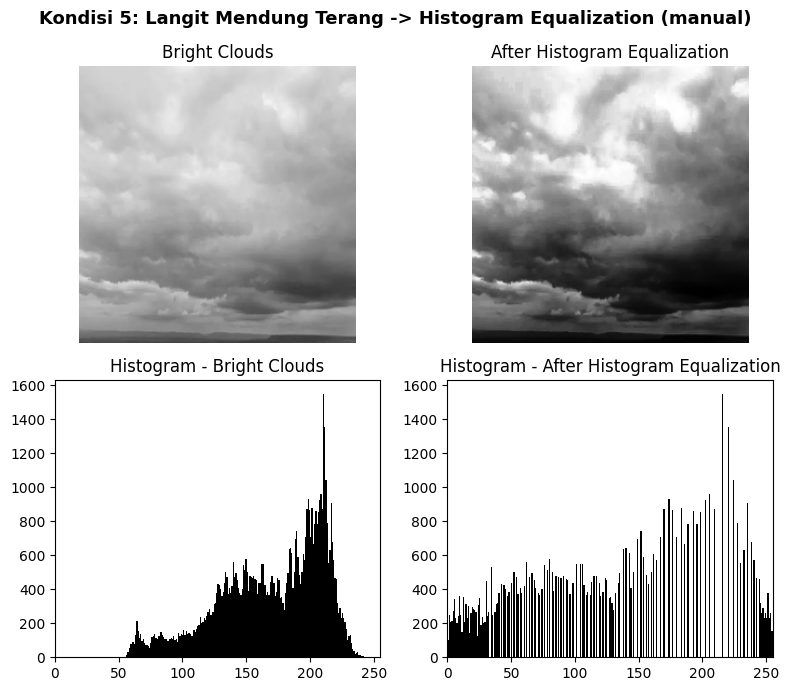

Mean before = 169.96 | Mean after = 128.56


In [16]:
img5 = load_scene("05_langit_mendung.jpg")
eq5, _, _ = histogram_equalization(img5)

show_result(img5, eq5, "Bright Clouds", "After Histogram Equalization",
            title="Kondisi 5: Langit Mendung Terang -> Histogram Equalization (manual)")

## Kondisi 6: Low-Contrast Image &rarr; Contrast Stretching

**Citra sumber:** Pelabuhan berkabut

**Ciri-ciri:** kabut tebal membuat seluruh rentang intensitas citra
menyempit di sekitar nilai tengah.

**Metode:** *Piecewise-Linear Contrast Stretching*
`P_out = (P_in - Min) * (b-a)/(Max-Min) + a`, meregangkan rentang nilai
sempit tersebut ke seluruh rentang [0, 255] agar siluet kapal lebih jelas.

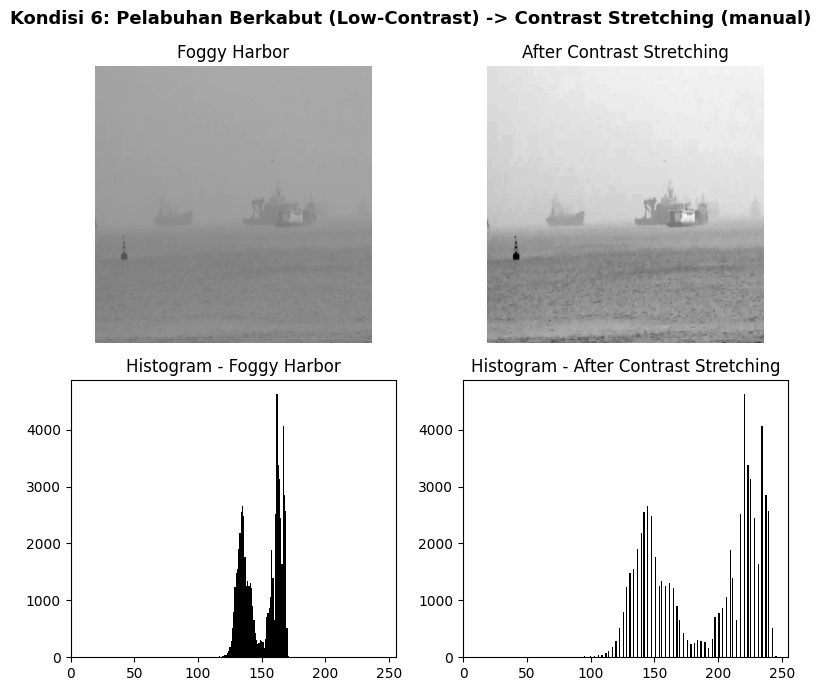

Mean before = 150.64 | Mean after = 189.01


In [17]:
img6 = load_scene("06_pelabuhan_berkabut.jpg")
stretch6 = contrast_stretching(img6)

show_result(img6, stretch6, "Foggy Harbor", "After Contrast Stretching",
            title="Kondisi 6: Pelabuhan Berkabut (Low-Contrast) -> Contrast Stretching (manual)")

## Kondisi 7: Detail Gelap di Latar Terang &rarr; Image Negative

**Citra sumber:** Rontgen tangan kuno

**Ciri-ciri:** citra medis (rontgen) dengan tulang tampak gelap di atas
latar terang ("film positif") secara visual lebih sulit dibaca
dibanding tampilan rontgen konvensional.

**Metode:** *Image Negative* `s = (L-1) - r`. Membalik seluruh skala
intensitas sehingga tulang tampak terang di latar gelap — tampilan khas
citra rontgen yang lebih mudah dianalisis (sesuai contoh mammogram di
materi kuliah).

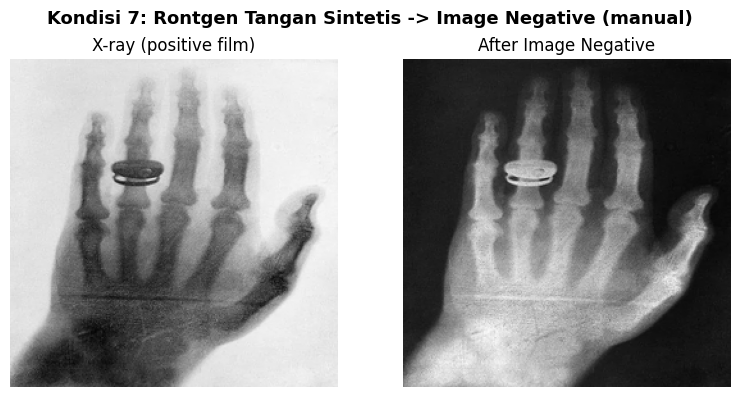

Mean before = 167.54 | Mean after = 87.46


In [18]:
img7 = load_scene("07_rontgen_tangan.jpg")
neg7 = image_negative(img7)

show_result(img7, neg7, "X-ray (positive film)", "After Image Negative",
            title="Kondisi 7: Rontgen Tangan Sintetis -> Image Negative (manual)",
            show_hist=False)

## Kondisi 8: Perlu Menonjolkan Rentang Intensitas Tertentu &rarr; Gray-Level Slicing

**Citra sumber:** Peta termal (thermal map)

**Ciri-ciri:** peta termal dengan beberapa "titik panas" (hot-spot) yang
ingin dianalisis secara khusus, sementara area bersuhu rendah/sedang tidak
terlalu penting namun tetap ingin dipertahankan sebagai konteks.

**Metode:** *Gray-level Slicing* — piksel dalam rentang `[170, 255]`
(area terpanas) dinaikkan menjadi nilai maksimum (highlight), sedangkan
piksel lain tetap dipertahankan.

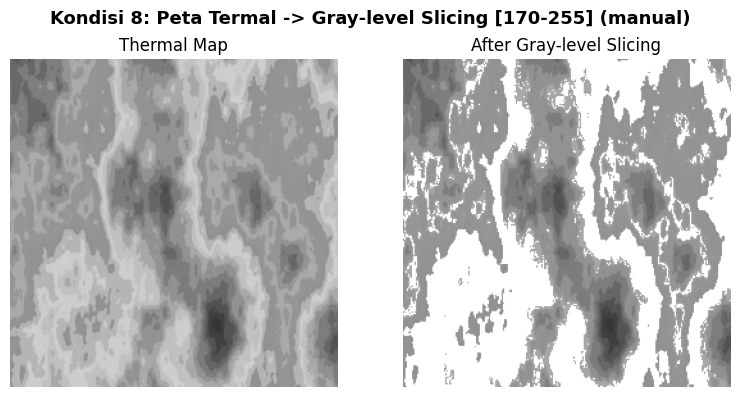

Mean before = 160.26 | Mean after = 185.71


In [19]:
img8 = load_scene("08_peta_termal.jpg")
sliced8 = gray_level_slicing(img8, A=170, B=255, preserve_background=True)

show_result(img8, sliced8, "Thermal Map", "After Gray-level Slicing",
            title="Kondisi 8: Peta Termal -> Gray-level Slicing [170-255] (manual)",
            show_hist=False)

## Kondisi 9: Noise Ringan di Bit Rendah &rarr; Bit-Plane Slicing & Reconstruction

**Citra sumber:** Hasil scan koran lama.

**Ciri-ciri:** hasil scan dokumen lama biasanya mengandung noise sensor
ringan (grain) yang sebagian besar mempengaruhi bit-bit rendah (LSB) dari
representasi biner tiap piksel, sementara bentuk huruf/blok teks utama
tersimpan di bit-bit tinggi (MSB).

**Metode:** *Bit-plane Slicing* memecah citra 8-bit menjadi 8 lapisan bit.
Dengan membuang plane LSB (3 bit terendah) dan merekonstruksi citra hanya
dari plane MSB, noise berkurang tanpa perlu filtering spasial.

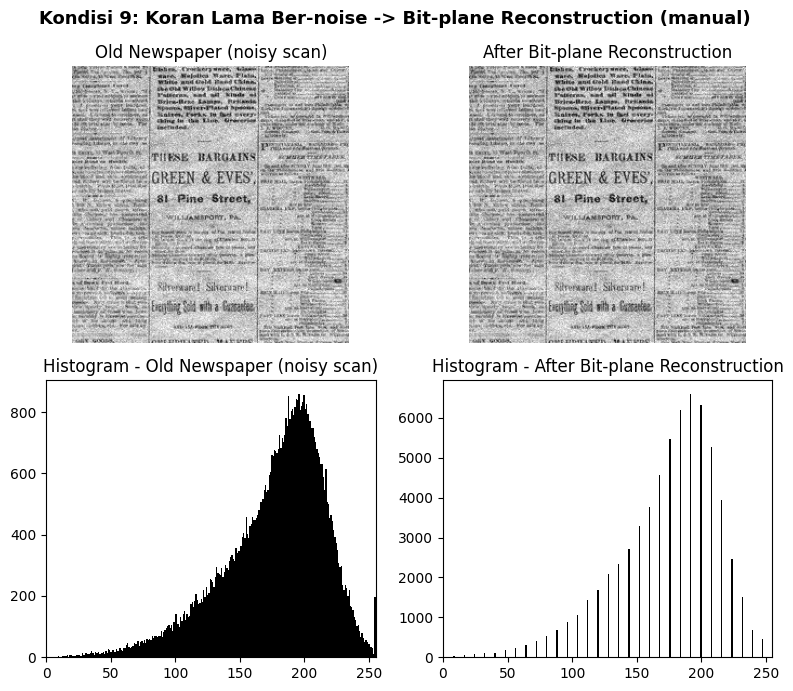

Mean before = 176.82 | Mean after = 173.32


In [20]:
img9_clean = load_scene("09_koran_lama.jpg")
img9 = add_gaussian_noise(img9_clean, sigma=18, seed=9)
planes9 = bit_plane_slicing(img9)
recon9 = bit_plane_reconstruct(img9, planes_to_keep=[3, 4, 5, 6, 7])

show_result(img9, recon9, "Old Newspaper (noisy scan)", "After Bit-plane Reconstruction",
            title="Kondisi 9: Koran Lama Ber-noise -> Bit-plane Reconstruction (manual)")

**Visualisasi 8 bit-plane** (MSB ke LSB) dari citra koran ber-noise.

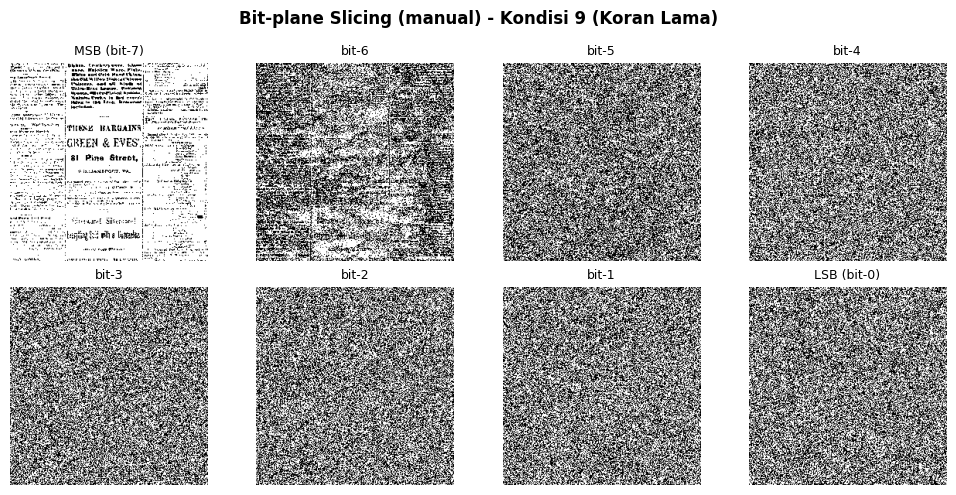

In [21]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))
for idx, ax in enumerate(axs.flat):
    bit_idx = 7 - idx
    ax.imshow(planes9[bit_idx], cmap="gray")
    label = "MSB (bit-7)" if bit_idx == 7 else ("LSB (bit-0)" if bit_idx == 0 else f"bit-{bit_idx}")
    ax.set_title(label, fontsize=9); ax.axis("off")
fig.suptitle("Bit-plane Slicing (manual) - Kondisi 9 (Koran Lama)", fontweight="bold")
fig.tight_layout()
plt.show()

## Kondisi 10: Salt & Pepper Noise &rarr; Median Filter

**Citra sumber:** Lukisan keranjang buah

**Ciri-ciri:** bintik-bintik khas
salt & pepper di atas gambar still-life buah-buahan.

**Metode:** *Median Filter* (3x3) — mengganti tiap piksel dengan nilai
median dari tetangganya. Sangat efektif menghilangkan noise impulsif
**tanpa** membuat citra menjadi blur (berbeda dari mean filter).

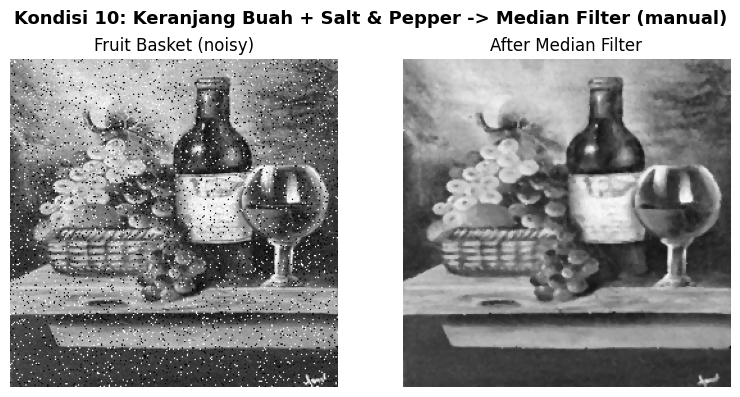

Mean before = 121.79 | Mean after = 121.28


In [22]:
img10_clean = load_scene("10_keranjang_buah.jpg")
img10 = add_salt_pepper_noise(img10_clean, amount=0.07, seed=10)
median10 = median_filter_manual(img10, ksize=3)

show_result(img10, median10, "Fruit Basket (noisy)", "After Median Filter",
            title="Kondisi 10: Keranjang Buah + Salt & Pepper -> Median Filter (manual)",
            show_hist=False)

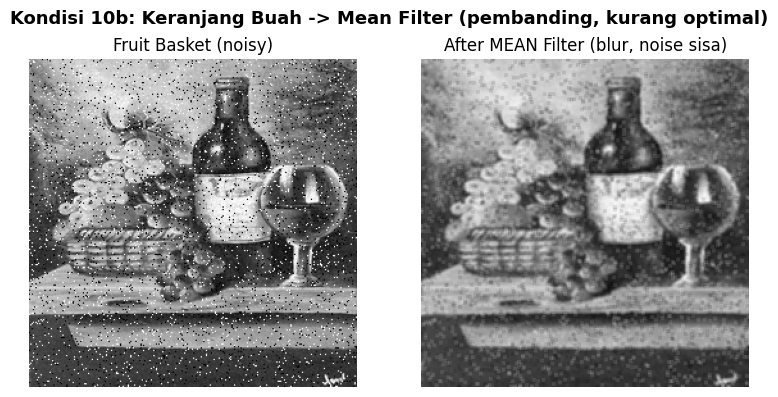

Mean before = 121.79 | Mean after = 121.34


In [23]:
mean10 = mean_filter(img10, ksize=3)

show_result(img10, mean10, "Fruit Basket (noisy)", "After MEAN Filter (blur, noise sisa)",
            title="Kondisi 10b: Keranjang Buah -> Mean Filter (pembanding, kurang optimal)",
            show_hist=False)

## Kondisi 11: Gaussian / Random Noise &rarr; Gaussian Smoothing Filter

**Citra sumber:** Nebula (foto luar angkasa)

**Ciri-ciri:** noise sensor kamera teleskop khas foto astronomi, yaitu grain
acak halus tersebar merata mengikuti distribusi normal di seluruh piksel.

**Metode:** *Gaussian Smoothing Filter* (low-pass) meredam variasi acak berfrekuensi tinggi
sambil tetap mempertahankan gradasi cahaya nebula yang halus.

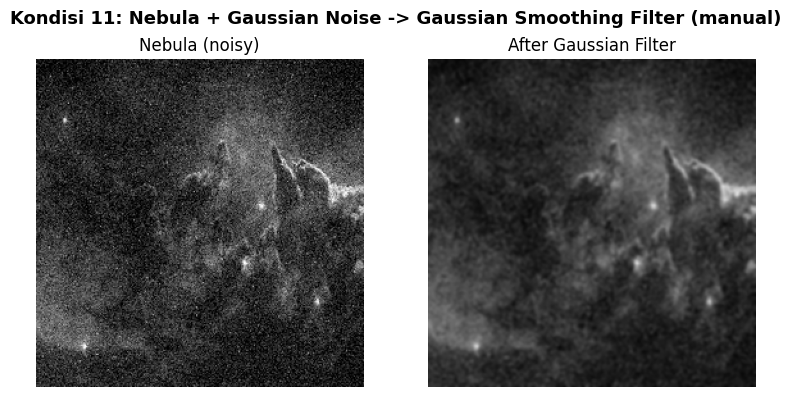

Mean before = 53.34 | Mean after = 52.84


In [24]:
img11_clean = load_scene("11_nebula.jpg")
img11 = add_gaussian_noise(img11_clean, sigma=22, seed=11)
gauss11 = gaussian_filter(img11, ksize=5, sigma=1.2)

show_result(img11, gauss11, "Nebula (noisy)", "After Gaussian Filter",
            title="Kondisi 11: Nebula + Gaussian Noise -> Gaussian Smoothing Filter (manual)",
            show_hist=False)

## Kondisi 12: Banyak Frame Noisy dari Objek yang Sama &rarr; Image Averaging

**Citra sumber:** Gugus bintang (galaxy cluster)

**Ciri-ciri:** teleskop mengambil beberapa (K) foto berturut-turut dari
gugus bintang yang sama, masing-masing dengan realisasi noise sensor acak
yang berbeda (skenario umum di astrofotografi long-exposure).

**Metode:** *Image Averaging* `ḡ(x,y) = (1/K)·Σ gᵢ(x,y)`. Karena noise
bersifat acak & independen (rata-rata nol), noise saling meredam saat
dirata-ratakan sedangkan posisi bintang tetap konsisten antar frame,
sehingga SNR meningkat.

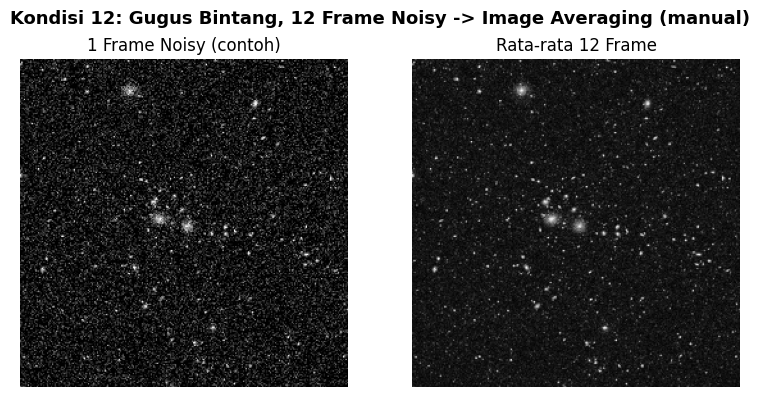

Mean before = 24.68 | Mean after = 24.18


In [25]:
img12_clean = load_scene("12_gugus_bintang.jpg")
K = 12
frames12 = [add_gaussian_noise(img12_clean, sigma=40, seed=200 + i) for i in range(K)]
avg12 = image_averaging(frames12)

show_result(frames12[0], avg12, "1 Frame Noisy (contoh)", f"Rata-rata {K} Frame",
            title=f"Kondisi 12: Gugus Bintang, {K} Frame Noisy -> Image Averaging (manual)",
            show_hist=False)

## Kondisi 13: Blurred Image &rarr; Sharpening (Laplacian Filter)

**Citra sumber:** Siluet kota (city skyline)

**Ciri-ciri:** foto skyline kota yang kabur (out-of-focus / hasil kompresi),
detail jendela-jendela gedung yang seharusnya tajam menjadi menyatu dan
tidak jelas.

**Metode:** *Laplacian Sharpening* — operator turunan kedua menonjolkan
perubahan intensitas tajam (tepi jendela & siluet gedung). Karena mask yang
dipakai memiliki koefisien tengah negatif, hasil Laplacian **dikurangkan**
dari citra: `g(x,y) = f(x,y) - ∇²f(x,y)`.

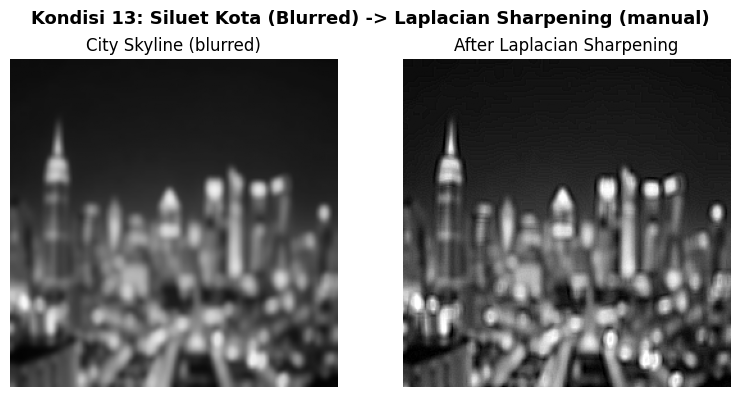

Mean before = 69.32 | Mean after = 69.30


In [26]:
img13_clean = load_scene("13_siluet_kota.jpg")
blur13 = mean_filter(img13_clean, ksize=5)
sharp13 = laplacian_sharpen(blur13, mode="8-neighbor")

show_result(blur13, sharp13, "City Skyline (blurred)", "After Laplacian Sharpening",
            title="Kondisi 13: Siluet Kota (Blurred) -> Laplacian Sharpening (manual)",
            show_hist=False)

## Kondisi 14: Soft-Focus / Sedikit Blur &rarr; Unsharp Masking

**Citra sumber:** Bunga makro (flower macro)

**Ciri-ciri:** foto makro bunga dengan sedikit blur (soft-focus akibat
getaran kamera ringan). Tepi kelopak masih ada tapi kurang tegas, butuh
penajaman yang halus/terkontrol dibanding Laplacian murni.

**Metode:** *Unsharp Masking*: (1) buat versi blur dari citra,
(2) `mask = original - blurred` (detail frekuensi tinggi yang hilang),
(3) `sharpened = original + k·mask`. Faktor `k = 1.6` mengontrol kekuatan
penajaman (high-boost).

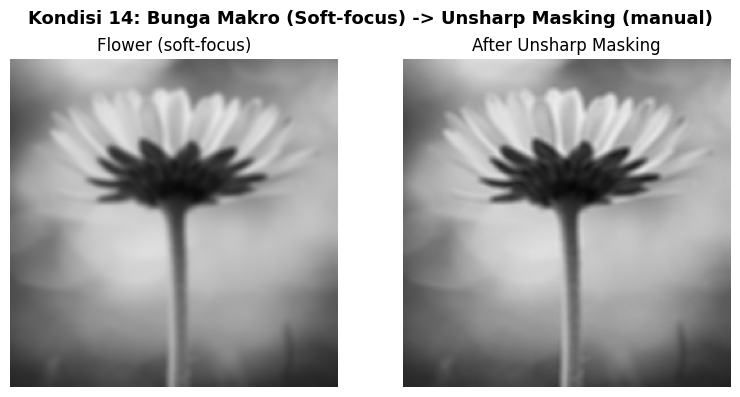

Mean before = 145.48 | Mean after = 145.95


In [27]:
img14_clean = load_scene("14_bunga_makro.jpg")
soft14 = gaussian_filter(img14_clean, ksize=7, sigma=2.2)
unsharp14 = unsharp_masking(soft14, ksize=5, sigma=1.5, k=1.6)

show_result(soft14, unsharp14, "Flower (soft-focus)", "After Unsharp Masking",
            title="Kondisi 14: Bunga Makro (Soft-focus) -> Unsharp Masking (manual)",
            show_hist=False)

## Kondisi 15: Periodic / Interference Noise &rarr; Frequency-Domain Low-Pass Filter

**Citra sumber:** Kain tenun bergaris (woven fabric)

**Ciri-ciri:** foto kain tenun bermotif garis-garis halus.

**Metode:** *Filtering Domain Frekuensi* — citra ditransformasi ke domain
frekuensi (DFT), dikalikan dengan mask *Gaussian Low-Pass* `H(u,v)`
(cut-off `D0=22`) yang didesain manual agar hanya meredam komponen frekuensi
tinggi (noise), lalu dikembalikan ke domain spasial (Inverse DFT).

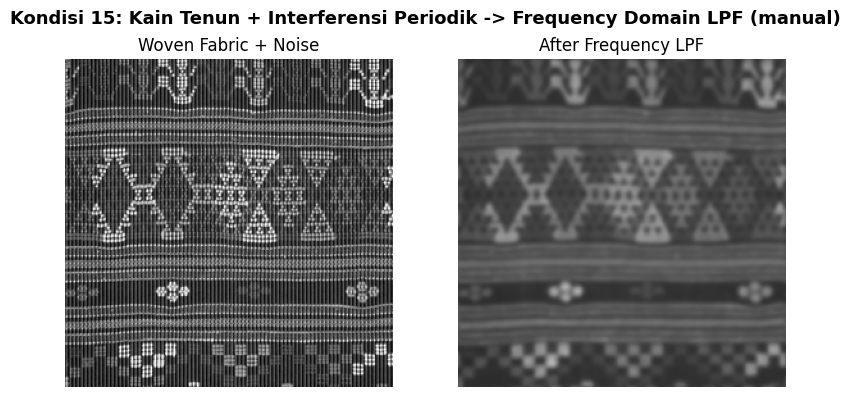

Mean before = 81.61 | Mean after = 81.11


In [28]:
img15_clean = load_scene("15_kain_tenun.jpg")
h, w = img15_clean.shape
xx, yy = np.meshgrid(np.arange(w), np.arange(h))
periodic_noise = 45 * np.sin(2 * np.pi * xx / 3)
img15 = np.clip(img15_clean.astype(np.float64) + periodic_noise, 0, 255).astype(np.uint8)

filt15, spectrum15, mask15 = frequency_lowpass_filter(img15, D0=22)

show_result(img15, filt15, "Woven Fabric + Noise", "After Frequency LPF",
            title="Kondisi 15: Kain Tenun + Interferensi Periodik -> Frequency Domain LPF (manual)",
            show_hist=False)

**Detail proses:** citra + noise, spektrum magnitude `|F(u,v)|` (skala log — pola bintik/garis terang menandakan komponen frekuensi tinggi dari noise), dan mask Gaussian Low-Pass `H(u,v)` yang dipakai untuk meredamnya.

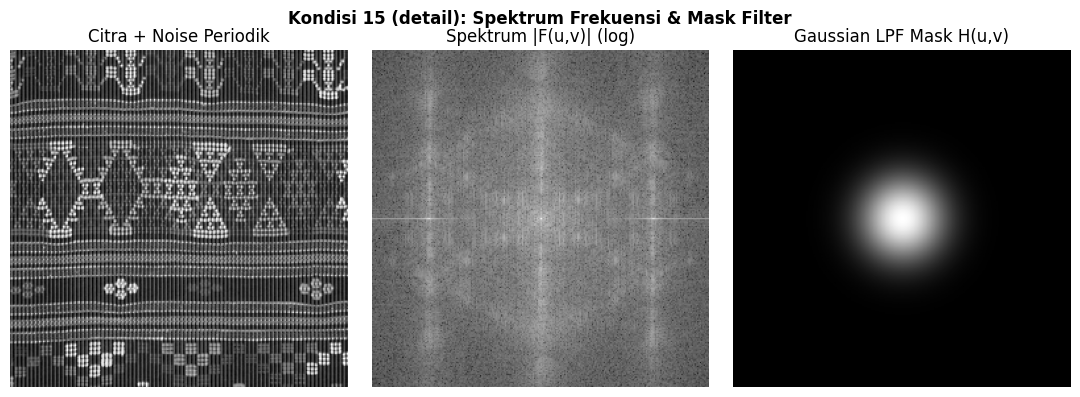

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(11, 4))
ax[0].imshow(img15, cmap="gray"); ax[0].set_title("Citra + Noise Periodik"); ax[0].axis("off")
ax[1].imshow(spectrum15, cmap="gray"); ax[1].set_title("Spektrum |F(u,v)| (log)"); ax[1].axis("off")
ax[2].imshow(mask15, cmap="gray"); ax[2].set_title("Gaussian LPF Mask H(u,v)"); ax[2].axis("off")
fig.suptitle("Kondisi 15 (detail): Spektrum Frekuensi & Mask Filter", fontweight="bold")
fig.tight_layout()
plt.show()

## Kesimpulan

| Kategori | Kondisi Citra | Citra Sumber | Metode Terbaik | Sifat |
|---|---|---|---|---|
| Pixel-based (data independent) | Dark image | Potret gelap / gang malam / gua | Histogram Eq. / Log / Gamma (γ<1) | cepat, sebagian perlu parameter manual |
| Pixel-based (data dependent) | Bright / low-contrast | Salju / awan / pelabuhan kabut | Histogram Eq. / Gamma (γ>1) / Contrast Stretch | otomatis, adaptif ke data |
| Pixel-based | Detail gelap di bg terang | Rontgen tangan | Image Negative | sederhana, langsung |
| Pixel-based | Highlight rentang tertentu | Peta termal | Gray-level Slicing | selektif |
| Pixel-based | Noise di bit rendah | Koran lama | Bit-plane Reconstruction | tanpa filtering spasial |
| Spatial filtering | Salt & pepper noise | Keranjang buah | Median Filter | non-linear, tidak mem-blur |
| Spatial filtering | Gaussian noise | Nebula | Gaussian Filter | linear, sedikit blur |
| Spatial filtering | Blurred image | Siluet kota | Laplacian Sharpening | menonjolkan tepi |
| Spatial filtering | Soft blur | Bunga makro | Unsharp Masking | penajaman terkontrol (k) |
| Multi-frame | Noise acak, banyak frame | Gugus bintang | Image Averaging | SNR naik ~√K |
| Frequency domain | Periodic noise | Kain tenun | Gaussian Low-Pass Filter | efektif utk noise berpola |

**Kesimpulan:** tidak ada satu metode yang universal. Pemilihan metode
enhancement harus disesuaikan dengan **karakteristik histogram** dan
**jenis masalah** pada citra (pixel-based untuk masalah kecerahan/kontras,
spatial filtering untuk noise/blur, frequency domain untuk noise berpola/
periodik).